In [1]:
%load_ext autoreload
%autoreload 2
from copy import deepcopy
from pathlib import Path

import gymnasium as gym
import highway_env  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output

from shared_core_config import SHARED_CORE_CONFIG, SHARED_CORE_ENV_ID, CNN_TRAIN_CONFIG, CNN_CORE_CONFIG

from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage

In [2]:
def make_env(config, render_mode=None):
    """Create a single gymnasium environment with the specified config."""
    env = gym.make(SHARED_CORE_ENV_ID, config=config, render_mode=render_mode)
    env.reset()
    if render_mode == "rgb_array":
        env.unwrapped.viewer = None
        env.unwrapped.config["offscreen_rendering"] = True
    return env


def make_vec_env(config):
    """Create a vectorized environment (DummyVecEnv wrapper)."""
    vec_env = DummyVecEnv([lambda: make_env(config, render_mode=None)])
    # Transpose image if observation is in (H, W, C) format
    if len(vec_env.observation_space.shape) == 3 and vec_env.observation_space.shape[-1] in (1, 3, 4):
        vec_env = VecTransposeImage(vec_env)
    return vec_env


# Train and evaluate on the same image observation space.
TRAIN_CONFIG = CNN_TRAIN_CONFIG
EVAL_CONFIG = CNN_CORE_CONFIG

# Separate env only for optional sanity-check visualizations.
env = make_env(TRAIN_CONFIG, render_mode="rgb_array")
print("Training config observation type:", TRAIN_CONFIG["observation"]["type"])
print("Evaluation config observation type:", EVAL_CONFIG["observation"]["type"])
print("Action space:", env.action_space)
print("Training observation space:", env.observation_space)

Training config observation type: GrayscaleObservation
Evaluation config observation type: GrayscaleObservation
Action space: Discrete(5)
Training observation space: Box(0, 255, (4, 180, 64), uint8)


Raw observation shape: (4, 180, 64) dtype: uint8
reset channel 0: min=0 max=0 mean=0.00
reset channel 1: min=0 max=0 mean=0.00
reset channel 2: min=0 max=0 mean=0.00
reset channel 3: min=59 max=254 mean=109.78

After warmup steps:
warm channel 0: min=59 max=254 mean=109.78
warm channel 1: min=59 max=254 mean=109.67
warm channel 2: min=59 max=254 mean=109.82
warm channel 3: min=59 max=254 mean=109.82


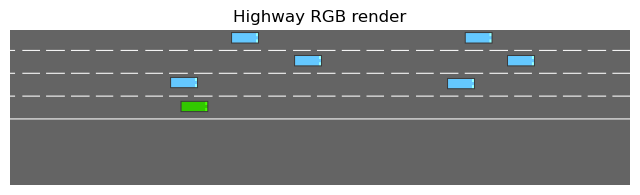

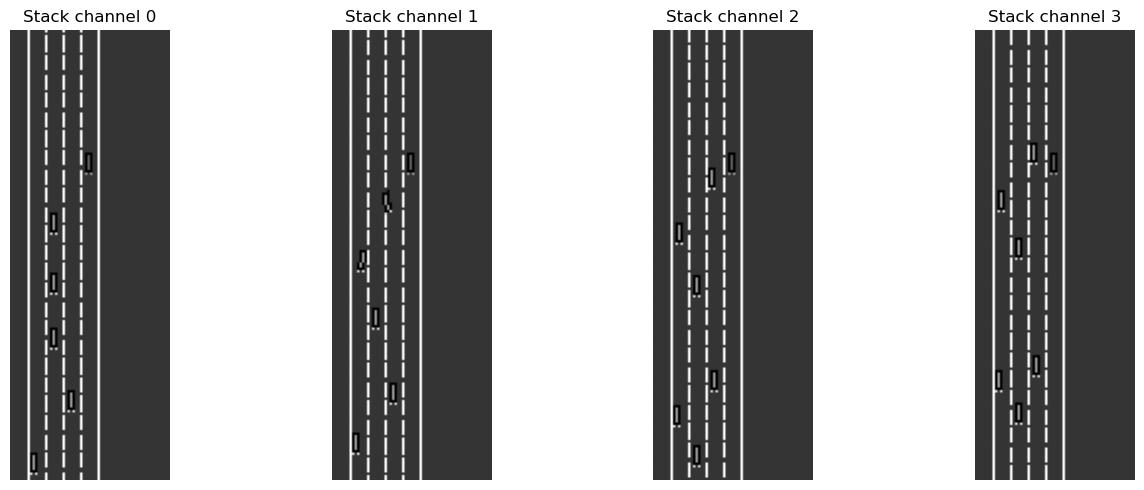

In [3]:
# Sanity check on stacked grayscale observations
obs, _ = env.reset()
print("Raw observation shape:", obs.shape, "dtype:", obs.dtype)

# Why some channels look black at reset: stack is progressively filled.
for c in range(obs.shape[0]):
    print(f"reset channel {c}: min={obs[c].min()} max={obs[c].max()} mean={obs[c].mean():.2f}")

# Fill the frame stack by stepping a few times
for _ in range(obs.shape[0] - 1):
    idle_action = env.unwrapped.action_type.actions_indexes["IDLE"]
    obs, _, terminated, truncated, _ = env.step(idle_action)
    if terminated or truncated:
        obs, _ = env.reset()

print("\nAfter warmup steps:")
for c in range(obs.shape[0]):
    print(f"warm channel {c}: min={obs[c].min()} max={obs[c].max()} mean={obs[c].mean():.2f}")

# RGB render (human-friendly)
plt.figure(figsize=(8, 3))
plt.imshow(env.render())
plt.axis("off")
plt.title("Highway RGB render")
plt.show()

# Visualize all stack channels with shared contrast for fair comparison
vmin, vmax = int(obs.min()), int(obs.max())
fig, axes = plt.subplots(1, obs.shape[0], figsize=(14, 5))
for c in range(obs.shape[0]):
    axes[c].imshow(obs[c], cmap="gray", vmin=vmin, vmax=vmax)
    axes[c].set_title(f"Stack channel {c}")
    axes[c].axis("off")
plt.tight_layout()
plt.show()

In [4]:
def evaluate_sb3_model(model, config, n_eval_episodes=20, deterministic=True):
    eval_vec_env = make_vec_env(config)
    mean_reward, std_reward = evaluate_policy(
        model,
        eval_vec_env,
        n_eval_episodes=n_eval_episodes,
        deterministic=deterministic,
    )
    eval_vec_env.close()
    return mean_reward, std_reward


def run_one_episode_sb3(model, config, max_steps=500, display=True):
    # Render only for visualization, never during training.
    vis_env = make_env(config, render_mode="rgb_array")
    obs, _ = vis_env.reset()
    done = False
    truncated = False
    total_reward = 0.0
    steps = 0

    while not (done or truncated) and steps < max_steps:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, _ = vis_env.step(int(action))
        total_reward += reward
        steps += 1

        if display:
            clear_output(wait=True)
            plt.figure(figsize=(8, 3))
            plt.imshow(vis_env.render())
            plt.axis("off")
            plt.title(f"Step={steps} | Total reward={total_reward:.2f}")
            plt.show()

    vis_env.close()
    print(f"Episode finished: steps={steps}, total_reward={total_reward:.2f}")
    return total_reward

## Training DQN (CnnPolicy) with image observations

This uses a local image config copy and keeps `shared_core_config.py` unchanged.

In [10]:
# Optional: uncomment if stable-baselines3 is not installed in the notebook kernel
# %pip install stable-baselines3[extra]

import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

train_env = make_vec_env(TRAIN_CONFIG)

model = DQN(
    policy="CnnPolicy",
    env=train_env,
    learning_rate=1e-4,
    buffer_size=1_000,
    learning_starts=5_000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=2_000,
    exploration_fraction=0.3,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.02,
    verbose=1,
    tensorboard_log=None,
    seed=42,
    device="cuda:0",
    optimize_memory_usage=False,
)

print("Starting training on CNN_TRAIN_CONFIG (GrayscaleObservation)...")
print("Evaluation will be done on the same image config for consistency.\n")

# Longer training is required for image-based DQN.
total_timesteps = 300_000
model.learn(total_timesteps=total_timesteps, progress_bar=True)


CUDA available: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU
Using cuda:0 device


MemoryError: Unable to allocate 43.9 MiB for an array with shape (1000, 1, 4, 180, 64) and data type uint8

In [ ]:
save_path = Path("models") / f"dqn_highway_cnn_pretrained_{total_timesteps}"
save_path.parent.mkdir(parents=True, exist_ok=True)
model.save(str(save_path))
print(f"\n Model saved to: {save_path}.zip")

train_env.close()

NameError: name 'Path' is not defined

In [ ]:
torch.cuda.empty_cache()
loaded_model = DQN.load(str(save_path))

print("="*60)
print("EVALUATION ON CNN_TRAIN_CONFIG (Image observation)")
print("="*60)

mean_reward, std_reward = evaluate_sb3_model(
    loaded_model,
    EVAL_CONFIG,
    n_eval_episodes=20,
    deterministic=True,
)
print(f"\n DQN-CNN Mean Reward: {mean_reward:.3f} ± {std_reward:.3f} (20 episodes)")

# Verify config used for training/evaluation
print(f"\nTraining config observation type: {TRAIN_CONFIG['observation']['type']}")
print(f"Evaluation config observation type: {EVAL_CONFIG['observation']['type']}")


EVALUATION ON SHARED_CORE_CONFIG (Kinematics observation)


c:\Users\coren\miniconda3\envs\pytorchEnv310\lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(



 DQN-CNN Mean Reward: 6.897 ± 4.243 (20 episodes)

Training config observation type: GrayscaleObservation
Evaluation config observation type: GrayscaleObservation


In [ ]:
class RandomPolicy:
    def __init__(self, action_space):
        self.action_space = action_space

    def predict(self, obs, deterministic=True):
        return self.action_space.sample(), None


def evaluate_random_policy(config, n_eval_episodes=20):
    rewards = []
    for ep in range(n_eval_episodes):
        env_rand = make_env(config)
        obs, _ = env_rand.reset()
        done = False
        truncated = False
        total_reward = 0.0
        random_policy = RandomPolicy(env_rand.action_space)

        while not (done or truncated):
            action, _ = random_policy.predict(obs)
            obs, reward, done, truncated, _ = env_rand.step(int(action))
            total_reward += reward

        rewards.append(total_reward)
        env_rand.close()

    rewards = np.array(rewards)
    return float(np.mean(rewards)), float(np.std(rewards))


print("\n" + "="*60)
print("RANDOM BASELINE (on SHARED_CORE_CONFIG)")
print("="*60)

random_mean, random_std = evaluate_random_policy(EVAL_CONFIG, n_eval_episodes=20)
print(f"\nRandom Policy Mean Reward: {random_mean:.3f} ± {random_std:.3f} (20 episodes)")
print(f"\nDQN vs Random Gain: {mean_reward - random_mean:.3f}")


KeyboardInterrupt: 

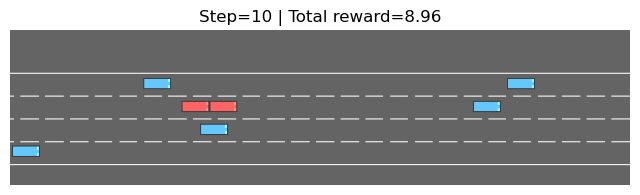

Episode finished: steps=10, total_reward=8.96


In [ ]:
# Visual rollout of the trained policy on SHARED_CORE_CONFIG
print("\n" + "="*60)
print("VISUAL ROLLOUT (on SHARED_CORE_CONFIG)")
print("="*60 + "\n")
_ = run_one_episode_sb3(loaded_model, EVAL_CONFIG, display=True)
